# Graph V1 Audit — Aletheia (PT)

**Executable audit** of the v1 Neo4j graph against the intended schema ([docs/graph_v1.md](../docs/graph_v1.md)) and the source dataset report ([reports/aletheia_pt_report.md](../reports/aletheia_pt_report.md)).

This notebook is idempotent: re-run it after every graph rebuild and compare the **Final Assessment** table at the bottom.  
Every check appends a row to a shared `AUDIT` log with `PASS` / `WARN` / `FAIL` status, and each query is shown inline with a short interpretation.

In [48]:
from neo4j import GraphDatabase
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

%matplotlib inline
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

In [49]:
driver = GraphDatabase.driver(
    "bolt://localhost:7687",
    auth=("neo4j", "aletheia2026")
)


def cypher(q, **params):
    # Run a Cypher query and return the result as a DataFrame.
    records, _, keys = driver.execute_query(q, parameters_=params, database_="neo4j")
    return pd.DataFrame([r.data() for r in records], columns=keys)


driver.verify_connectivity()
print("Connected to Neo4j at bolt://localhost:7687")

Connected to Neo4j at bolt://localhost:7687


## Audit framework
Shared helpers. `EXPECTED` holds the reference values taken from the dataset report. Every check calls `record(...)`; the final section renders the log.

In [50]:
# Reference values from reports/aletheia_pt_report.md (source of truth).
EXPECTED = {
    "messages": 32285,
    "dataset_channels": 109,
    "users": 5854,
    "messages_with_replies": 8315,
    "messages_forwarded_known_source": 4947,
    "known_forward_source_channels": 440,
    "known_reply_source_channels": 51,
    "user_channel_edges": 6337,
    "date_start": "2020-03-01",
    "date_end": "2025-06-10",
    "total_views": 123484688.0,
    "total_forwards": 640336.0,
    "total_reactions": 1606066,
}

# Expected graph schema (from docs/graph_v1.md + the load cypher files).
EXPECTED_LABELS = ["Channel", "User", "Message"]
EXPECTED_RELS = [
    "POSTED", "IN_CHANNEL", "ACTIVE_IN",
    "REPLIES_TO", "REPLIED_INTO", "FORWARDED_FROM",
    "INTERACTS_WITH",
]

AUDIT = []


def record(check, expected, actual, status=None, note=""):
    # Append one result row to the audit log; auto-derive PASS/FAIL on equality.
    if status is None:
        status = "PASS" if expected == actual else "FAIL"
    AUDIT.append(
        {"check": check, "expected": expected, "actual": actual,
         "status": status, "note": note}
    )
    print(f"[{status:4}] {check}: expected={expected} actual={actual}"
          + (f"  -- {note}" if note else ""))


def interp(text):
    # Render a short interpretation under a query result.
    display(Markdown(f"> **Interpretation:** {text}"))


def scalar(df, col=None):
    # Pull the single scalar value out of a one-row DataFrame.
    if col is None:
        col = df.columns[0]
    return df[col].iloc[0]

## 1. Neo4j database state
Node counts by label, relationship counts by type, and the presence of expected constraints/indexes.

In [51]:
# Cypher: node counts per label.
q_nodes = '''
MATCH (n)
UNWIND labels(n) AS label
RETURN label, count(*) AS count
ORDER BY count DESC
'''
node_counts = cypher(q_nodes)
display(node_counts)
interp('Label distribution in the live database. Message includes reply-target '
       'stubs created by REPLIES_TO; those are separated in section 6.')

,label,count
0,Message,39875
1,User,5854
2,Channel,477
3,GraphBuild,1


> **Interpretation:** Label distribution in the live database. Message includes reply-target stubs created by REPLIES_TO; those are separated in section 6.

In [52]:
# Cypher: relationship counts per type.
q_rels = '''
MATCH ()-[r]->()
RETURN type(r) AS rel_type, count(*) AS count
ORDER BY count DESC
'''
rel_counts = cypher(q_rels)
display(rel_counts)
interp('Relationship type distribution. Compared against EXPECTED_RELS in section 2.')

,rel_type,count
0,POSTED,32285
1,IN_CHANNEL,32285
2,REPLIES_TO,8315
3,REPLIED_INTO,8315
4,ACTIVE_IN,6337
5,FORWARDED_FROM,4312
6,INTERACTS_WITH,1154


> **Interpretation:** Relationship type distribution. Compared against EXPECTED_RELS in section 2.

In [53]:
# Cypher: declared constraints and indexes.
constraints = cypher('SHOW CONSTRAINTS')
indexes = cypher('SHOW INDEXES')
display(constraints)
display(indexes)

# Expect uniqueness constraints on Channel.id, User.id, Message.id and
# indexes on Message.month and Message.date_parsed (from constraints.cypher).
con_labels = set()
if not constraints.empty and 'labelsOrTypes' in constraints.columns:
    for lst in constraints['labelsOrTypes'].dropna():
        con_labels.update(lst or [])
for lbl in EXPECTED_LABELS:
    record(f'constraint exists for {lbl}', True, lbl in con_labels,
           status=('PASS' if lbl in con_labels else 'FAIL'))

idx_names = set(indexes['name']) if 'name' in indexes.columns else set()
for idx in ['message_month', 'message_date']:
    record(f'index exists: {idx}', True, idx in idx_names,
           status=('PASS' if idx in idx_names else 'WARN'),
           note='' if idx in idx_names else 'declared in constraints.cypher')
interp('Uniqueness constraints back the duplicate-id guarantees; the two Message '
       'indexes support temporal queries.')

,id,name,type,entityType,labelsOrTypes,properties,enforcedLabel,ownedIndex,propertyType
0,4,channel_id,NODE_PROPERTY_UNIQUENESS,NODE,[Channel],[id],None,channel_id,None
1,8,message_id,NODE_PROPERTY_UNIQUENESS,NODE,[Message],[id],None,message_id,None
2,6,user_id,NODE_PROPERTY_UNIQUENESS,NODE,[User],[id],None,user_id,None


,id,name,state,populationPercent,type,entityType,labelsOrTypes,properties,indexProvider,owningConstraint,lastRead,readCount
0,3,channel_id,ONLINE,100.0,RANGE,NODE,[Channel],[id],range-1.0,channel_id,2026-06-10T22:06:17.367000000+00:00,158926
1,2,index_1b9dcc97,ONLINE,100.0,LOOKUP,RELATIONSHIP,None,None,token-lookup-1.0,NaN,2026-06-10T22:06:21.570000000+00:00,15
2,1,index_460996c0,ONLINE,100.0,LOOKUP,NODE,None,None,token-lookup-1.0,NaN,2026-06-10T22:06:11.285000000+00:00,165
3,10,message_date,ONLINE,100.0,RANGE,NODE,[Message],[date_parsed],range-1.0,NaN,2026-06-10T18:41:07.544000000+00:00,4
4,7,message_id,ONLINE,100.0,RANGE,NODE,[Message],[id],range-1.0,message_id,2026-06-10T22:06:16.782000000+00:00,497963
5,9,message_month,ONLINE,100.0,RANGE,NODE,[Message],[month],range-1.0,NaN,2026-06-10T18:41:12.223000000+00:00,2
6,5,user_id,ONLINE,100.0,RANGE,NODE,[User],[id],range-1.0,user_id,2026-06-10T22:06:17.095000000+00:00,150992


[PASS] constraint exists for Channel: expected=True actual=True
[PASS] constraint exists for User: expected=True actual=True
[PASS] constraint exists for Message: expected=True actual=True
[PASS] index exists: message_month: expected=True actual=True
[PASS] index exists: message_date: expected=True actual=True


> **Interpretation:** Uniqueness constraints back the duplicate-id guarantees; the two Message indexes support temporal queries.

## 2. Schema conformance
Confirm the expected node labels and relationship types exist, and inventory the properties actually present on each (via `db.schema.*TypeProperties`).

In [54]:
present_labels = set(node_counts['label']) if not node_counts.empty else set()
present_rels = set(rel_counts['rel_type']) if not rel_counts.empty else set()

for lbl in EXPECTED_LABELS:
    record(f'label present: {lbl}', True, lbl in present_labels,
           status=('PASS' if lbl in present_labels else 'FAIL'))
for rel in EXPECTED_RELS:
    record(f'rel type present: {rel}', True, rel in present_rels,
           status=('PASS' if rel in present_rels else 'FAIL'))

unexpected_labels = present_labels - set(EXPECTED_LABELS)
unexpected_rels = present_rels - set(EXPECTED_RELS)
interp(f'Unexpected labels: {sorted(unexpected_labels) or "none"}. '
       f'Unexpected rel types: {sorted(unexpected_rels) or "none"}. '
       'A GraphBuild metadata node is expected (written by metadata.cypher).')

[PASS] label present: Channel: expected=True actual=True
[PASS] label present: User: expected=True actual=True
[PASS] label present: Message: expected=True actual=True
[PASS] rel type present: POSTED: expected=True actual=True
[PASS] rel type present: IN_CHANNEL: expected=True actual=True
[PASS] rel type present: ACTIVE_IN: expected=True actual=True
[PASS] rel type present: REPLIES_TO: expected=True actual=True
[PASS] rel type present: REPLIED_INTO: expected=True actual=True
[PASS] rel type present: FORWARDED_FROM: expected=True actual=True
[PASS] rel type present: INTERACTS_WITH: expected=True actual=True


> **Interpretation:** Unexpected labels: ['GraphBuild']. Unexpected rel types: none. A GraphBuild metadata node is expected (written by metadata.cypher).

In [55]:
# Cypher: property inventory per node label.
node_props = cypher('''
CALL db.schema.nodeTypeProperties()
YIELD nodeLabels, propertyName, propertyTypes, mandatory
RETURN nodeLabels, propertyName, propertyTypes, mandatory
ORDER BY nodeLabels, propertyName
''')
display(node_props)

# Required properties per label, per the load_nodes.cypher SET clauses.
REQUIRED_NODE_PROPS = {
    'Channel': ['id', 'total_messages', 'total_users', 'active_start',
                'active_end', 'total_views', 'total_forwards', 'total_reactions',
                'is_dataset_channel', 'is_forward_source', 'is_reply_source'],
    'User': ['id', 'total_messages', 'channel_count'],
    'Message': ['id', 'text_content', 'date_parsed', 'month', 'text_length',
                'word_count', 'views', 'reactions', 'n_forwards',
                'is_reply', 'is_forwarded'],
}

def props_for(label):
    out = set()
    for _, r in node_props.iterrows():
        if label in (r['nodeLabels'] or []):
            out.add(r['propertyName'])
    return out

for label, req in REQUIRED_NODE_PROPS.items():
    have = props_for(label)
    missing = [p for p in req if p not in have]
    record(f'{label} has required properties', [], missing,
           status=('PASS' if not missing else 'FAIL'),
           note=('all present' if not missing else f'missing {missing}'))
interp('Property names compared against the SET clauses in load_nodes.cypher.')

,nodeLabels,propertyName,propertyTypes,mandatory
0,[Channel],active_end,[STRING NOT NULL],False
1,[Channel],active_start,[STRING NOT NULL],False
2,[Channel],id,[STRING NOT NULL],True
3,[Channel],is_dataset_channel,[BOOLEAN NOT NULL],True
4,[Channel],is_forward_source,[BOOLEAN NOT NULL],True
5,[Channel],is_reply_source,[BOOLEAN NOT NULL],True
6,[Channel],total_forwards,[FLOAT NOT NULL],True
7,[Channel],total_messages,[INTEGER NOT NULL],True
8,[Channel],total_reactions,[INTEGER NOT NULL],True
9,[Channel],total_users,[INTEGER NOT NULL],True


[PASS] Channel has required properties: expected=[] actual=[]  -- all present
[PASS] User has required properties: expected=[] actual=[]  -- all present
[PASS] Message has required properties: expected=[] actual=[]  -- all present


> **Interpretation:** Property names compared against the SET clauses in load_nodes.cypher.

In [56]:
# Cypher: property inventory per relationship type.
rel_props = cypher('''
CALL db.schema.relTypeProperties()
YIELD relType, propertyName, propertyTypes, mandatory
RETURN relType, propertyName, propertyTypes, mandatory
ORDER BY relType, propertyName
''')
display(rel_props)

# docs/graph_v1.md asks for richer rel properties than the loader actually sets.
# ACTIVE_IN: doc wants messages_count/first_seen/last_seen; loader sets
#   total_messages/total_views/total_reactions/total_forwards.
# REPLIES_TO: doc wants reply_timestamp/same_channel; loader sets none.
active_in_props = set(rel_props.loc[rel_props['relType'].str.contains('ACTIVE_IN'),
                                    'propertyName'].dropna())
record('ACTIVE_IN aggregate props present', True,
       {'total_messages', 'total_views', 'total_reactions', 'total_forwards'}
       <= active_in_props,
       status=('PASS' if {'total_messages','total_views','total_reactions',
               'total_forwards'} <= active_in_props else 'FAIL'))
record('ACTIVE_IN uses doc name messages_count', True,
       'messages_count' in active_in_props, status='WARN',
       note='loader uses total_messages instead of doc field messages_count')
record('ACTIVE_IN has first_seen/last_seen', True,
       {'first_seen','last_seen'} <= active_in_props, status='WARN',
       note='doc asks for first_seen/last_seen; loader omits them')
record('REPLIES_TO has same_channel/reply_timestamp', True,
       not rel_props.loc[rel_props['relType'].str.contains('REPLIES_TO')].empty
       and {'same_channel','reply_timestamp'} <=
       set(rel_props.loc[rel_props['relType'].str.contains('REPLIES_TO'),
           'propertyName'].dropna()), status='WARN',
       note='doc asks for same_channel/reply_timestamp; loader sets neither')
interp('Relationship properties diverge from docs/graph_v1.md: ACTIVE_IN field '
       'naming and the REPLIES_TO enrichment fields are not implemented.')

,relType,propertyName,propertyTypes,mandatory
0,:`ACTIVE_IN`,total_forwards,[FLOAT NOT NULL],True
1,:`ACTIVE_IN`,total_messages,[INTEGER NOT NULL],True
2,:`ACTIVE_IN`,total_reactions,[INTEGER NOT NULL],True
3,:`ACTIVE_IN`,total_views,[FLOAT NOT NULL],True
4,:`FORWARDED_FROM`,NaN,None,False
5,:`INTERACTS_WITH`,forward_count,[INTEGER NOT NULL],True
6,:`INTERACTS_WITH`,has_forward_signal,[BOOLEAN NOT NULL],True
7,:`INTERACTS_WITH`,has_reply_signal,[BOOLEAN NOT NULL],True
8,:`INTERACTS_WITH`,has_shared_user_signal,[BOOLEAN NOT NULL],True
9,:`INTERACTS_WITH`,interaction_count,[INTEGER NOT NULL],True


[PASS] ACTIVE_IN aggregate props present: expected=True actual=True
[WARN] ACTIVE_IN uses doc name messages_count: expected=True actual=False  -- loader uses total_messages instead of doc field messages_count
[WARN] ACTIVE_IN has first_seen/last_seen: expected=True actual=False  -- doc asks for first_seen/last_seen; loader omits them
[WARN] REPLIES_TO has same_channel/reply_timestamp: expected=True actual=False  -- doc asks for same_channel/reply_timestamp; loader sets neither


> **Interpretation:** Relationship properties diverge from docs/graph_v1.md: ACTIVE_IN field naming and the REPLIES_TO enrichment fields are not implemented.

In [57]:
# Sparsity scan: fraction of NULL / empty-string values for key node properties.
def sparsity(label, prop):
    df = cypher(f'''
    MATCH (n:{label})
    RETURN count(*) AS total,
           sum(CASE WHEN n.{prop} IS NULL THEN 1 ELSE 0 END) AS nulls,
           sum(CASE WHEN n.{prop} = '' THEN 1 ELSE 0 END) AS empties
    ''')
    t = scalar(df, 'total') or 0
    nl = scalar(df, 'nulls') or 0
    em = scalar(df, 'empties') or 0
    pct = round(100 * (nl + em) / t, 2) if t else 0.0
    return {'label': label, 'property': prop, 'total': t,
            'null': nl, 'empty': em, 'missing_pct': pct}

rows = []
for label, req in REQUIRED_NODE_PROPS.items():
    for p in req:
        rows.append(sparsity(label, p))
sparsity_df = pd.DataFrame(rows).sort_values('missing_pct', ascending=False)
display(sparsity_df)
sparse = sparsity_df[sparsity_df['missing_pct'] > 0]
record('no sparsely-populated required props (>0% missing)', 0, len(sparse),
       status=('PASS' if sparse.empty else 'WARN'),
       note='' if sparse.empty else 'active_start/active_end blank for non-dataset channels is expected')
interp('High missingness on Channel.active_start/active_end is expected for '
       'external forward/reply-source channels that have no dataset messages.')

,label,property,total,null,empty,missing_pct
4,Channel,active_end,477,368,0,77.15
3,Channel,active_start,477,368,0,77.15
18,Message,text_length,39875,7590,0,19.03
19,Message,word_count,39875,7590,0,19.03
20,Message,views,39875,7590,0,19.03
21,Message,reactions,39875,7590,0,19.03
22,Message,n_forwards,39875,7590,0,19.03
16,Message,date_parsed,39875,7590,0,19.03
15,Message,text_content,39875,7590,0,19.03
23,Message,is_reply,39875,7590,0,19.03


[WARN] no sparsely-populated required props (>0% missing): expected=0 actual=12  -- active_start/active_end blank for non-dataset channels is expected


> **Interpretation:** High missingness on Channel.active_start/active_end is expected for external forward/reply-source channels that have no dataset messages.

## 3. Dataset-to-graph count validation
Compare live graph counts against the report reference values in `EXPECTED`.

In [58]:
# Cypher: the headline counts.
real_msgs = scalar(cypher(
    'MATCH (m:Message) WHERE m.is_stub IS NULL RETURN count(*) AS c'), 'c')
stub_msgs = scalar(cypher(
    'MATCH (m:Message) WHERE m.is_stub = true RETURN count(*) AS c'), 'c')
n_users = scalar(cypher('MATCH (u:User) RETURN count(*) AS c'), 'c')
n_dataset_ch = scalar(cypher(
    'MATCH (c:Channel) WHERE c.is_dataset_channel = true RETURN count(*) AS c'), 'c')
n_all_ch = scalar(cypher('MATCH (c:Channel) RETURN count(*) AS c'), 'c')
n_reply_msgs = scalar(cypher(
    'MATCH (m:Message) WHERE m.is_reply = true RETURN count(*) AS c'), 'c')
n_fwd_msgs = scalar(cypher(
    'MATCH (m:Message) WHERE m.is_forwarded = true RETURN count(*) AS c'), 'c')
n_fwd_src = scalar(cypher(
    'MATCH (c:Channel) WHERE c.is_forward_source = true RETURN count(*) AS c'), 'c')
n_reply_src = scalar(cypher(
    'MATCH (c:Channel) WHERE c.is_reply_source = true RETURN count(*) AS c'), 'c')

record('Message nodes (real, non-stub)', EXPECTED['messages'], real_msgs)
record('User nodes', EXPECTED['users'], n_users)
record('Dataset channels (is_dataset_channel)', EXPECTED['dataset_channels'], n_dataset_ch)
record('Messages with replies (is_reply)', EXPECTED['messages_with_replies'], n_reply_msgs)
record('Messages forwarded (is_forwarded)', EXPECTED['messages_forwarded_known_source'], n_fwd_msgs)
record('Known forward-source channels', EXPECTED['known_forward_source_channels'], n_fwd_src)
record('Known reply-source channels', EXPECTED['known_reply_source_channels'], n_reply_src)
print(f'Stub Message nodes (reply targets, no content): {stub_msgs}')
print(f'Total Channel nodes (dataset + external sources, deduped): {n_all_ch}')
interp('Real messages, users, and dataset channels should match exactly. '
       'is_forwarded messages (4947) count messages with any forward source; the '
       'FORWARDED_FROM edge count in section 7 is lower because only forwards with a '
       'recoverable CHANNEL_HASH produce an edge.')

[PASS] Message nodes (real, non-stub): expected=32285 actual=32285
[PASS] User nodes: expected=5854 actual=5854
[PASS] Dataset channels (is_dataset_channel): expected=109 actual=109
[PASS] Messages with replies (is_reply): expected=8315 actual=8315
[PASS] Messages forwarded (is_forwarded): expected=4947 actual=4947
[PASS] Known forward-source channels: expected=440 actual=440
[PASS] Known reply-source channels: expected=51 actual=51
Stub Message nodes (reply targets, no content): 7590
Total Channel nodes (dataset + external sources, deduped): 477


> **Interpretation:** Real messages, users, and dataset channels should match exactly. is_forwarded messages (4947) count messages with any forward source; the FORWARDED_FROM edge count in section 7 is lower because only forwards with a recoverable CHANNEL_HASH produce an edge.

## 4. Mandatory relationship validation
Every real `Message` must have exactly one incoming `POSTED` and exactly one outgoing `IN_CHANNEL`. Plus orphans, isolated users/channels, and duplicate ids.

In [59]:
# Cypher: POSTED cardinality per real message.
posted_card = cypher('''
MATCH (m:Message) WHERE m.is_stub IS NULL
OPTIONAL MATCH (u:User)-[p:POSTED]->(m)
WITH m, count(p) AS posted_in
RETURN posted_in, count(*) AS messages
ORDER BY posted_in
''')
display(posted_card)
bad_posted = int(posted_card.loc[posted_card['posted_in'] != 1, 'messages'].sum())
record('every real Message has exactly 1 POSTED', 0, bad_posted)

# Cypher: IN_CHANNEL cardinality per real message.
inch_card = cypher('''
MATCH (m:Message) WHERE m.is_stub IS NULL
OPTIONAL MATCH (m)-[ic:IN_CHANNEL]->(c:Channel)
WITH m, count(ic) AS in_channel
RETURN in_channel, count(*) AS messages
ORDER BY in_channel
''')
display(inch_card)
bad_inch = int(inch_card.loc[inch_card['in_channel'] != 1, 'messages'].sum())
record('every real Message has exactly 1 IN_CHANNEL', 0, bad_inch)
interp('A row at posted_in/in_channel == 1 covering all real messages is the pass '
       'condition. Stubs are excluded since they intentionally lack these edges.')

,posted_in,messages
0,1,32285


[PASS] every real Message has exactly 1 POSTED: expected=0 actual=0


,in_channel,messages
0,1,32285


[PASS] every real Message has exactly 1 IN_CHANNEL: expected=0 actual=0


> **Interpretation:** A row at posted_in/in_channel == 1 covering all real messages is the pass condition. Stubs are excluded since they intentionally lack these edges.

In [60]:
# Cypher: orphans and isolated nodes.
orphan_msgs = scalar(cypher('''
MATCH (m:Message) WHERE m.is_stub IS NULL
  AND NOT ( (:User)-[:POSTED]->(m) ) 
RETURN count(*) AS c'''), 'c')
users_no_msg = scalar(cypher('''
MATCH (u:User) WHERE NOT ( (u)-[:POSTED]->(:Message) )
RETURN count(*) AS c'''), 'c')
dataset_ch_no_msg = scalar(cypher('''
MATCH (c:Channel) WHERE c.is_dataset_channel = true
  AND NOT ( (:Message)-[:IN_CHANNEL]->(c) )
RETURN count(*) AS c'''), 'c')
record('orphan messages (no POSTED)', 0, orphan_msgs)
record('users without messages', 0, users_no_msg, status=('PASS' if users_no_msg == 0 else 'WARN'))
record('dataset channels without messages', 0, dataset_ch_no_msg,
       status=('PASS' if dataset_ch_no_msg == 0 else 'WARN'))
interp('Orphan messages should be zero. Isolated users/dataset-channels would '
       'indicate an aggregation node was created without its source messages.')

[PASS] orphan messages (no POSTED): expected=0 actual=0
[PASS] users without messages: expected=0 actual=0
[PASS] dataset channels without messages: expected=0 actual=0


> **Interpretation:** Orphan messages should be zero. Isolated users/dataset-channels would indicate an aggregation node was created without its source messages.

In [61]:
# Cypher: duplicate ids (uniqueness constraints should make these zero).
def dup_count(label):
    return scalar(cypher(f'''
    MATCH (n:{label})
    WITH n.id AS id, count(*) AS c WHERE c > 1
    RETURN count(*) AS dups'''), 'dups')

for label in EXPECTED_LABELS:
    d = dup_count(label)
    record(f'duplicate {label}.id values', 0, d)
interp('Backed by the uniqueness constraints from section 1; any non-zero value '
       'means a constraint is missing or was dropped.')

[PASS] duplicate Channel.id values: expected=0 actual=0
[PASS] duplicate User.id values: expected=0 actual=0
[PASS] duplicate Message.id values: expected=0 actual=0


> **Interpretation:** Backed by the uniqueness constraints from section 1; any non-zero value means a constraint is missing or was dropped.

## 5. Aggregated relationship validation — ACTIVE_IN
Validate `(User)-[:ACTIVE_IN]->(Channel)` edge count and that each edge's `total_messages` equals the messages that user actually posted in that channel. Also cross-check the summed engagement metrics.

In [62]:
# Cypher: ACTIVE_IN edge count vs report's user-channel edge count.
n_active = scalar(cypher('MATCH (:User)-[:ACTIVE_IN]->(:Channel) RETURN count(*) AS c'), 'c')
record('ACTIVE_IN edges', EXPECTED['user_channel_edges'], n_active)

# Cypher: does ACTIVE_IN.total_messages match the real posted-in-channel count?
active_mismatch = cypher('''
MATCH (u:User)-[r:ACTIVE_IN]->(c:Channel)
OPTIONAL MATCH (u)-[:POSTED]->(m:Message)-[:IN_CHANNEL]->(c)
WITH u, c, r.total_messages AS stored, count(m) AS actual
WHERE stored <> actual
RETURN count(*) AS mismatches
''')
n_mismatch = scalar(active_mismatch, 'mismatches')
record('ACTIVE_IN.total_messages == posted count', 0, n_mismatch)
interp('Every ACTIVE_IN edge weight should equal the number of messages that user '
       'posted in that channel via POSTED+IN_CHANNEL. Non-zero => the aggregate '
       'edge disagrees with the message-level graph.')

[PASS] ACTIVE_IN edges: expected=6337 actual=6337
[PASS] ACTIVE_IN.total_messages == posted count: expected=0 actual=0


> **Interpretation:** Every ACTIVE_IN edge weight should equal the number of messages that user posted in that channel via POSTED+IN_CHANNEL. Non-zero => the aggregate edge disagrees with the message-level graph.

In [63]:
# Cypher: do ACTIVE_IN engagement sums match aggregation of the member messages?
engage_check = cypher('''
MATCH (u:User)-[r:ACTIVE_IN]->(c:Channel)
OPTIONAL MATCH (u)-[:POSTED]->(m:Message)-[:IN_CHANNEL]->(c)
WITH u, c, r,
     sum(m.views) AS views_m,
     sum(m.reactions) AS react_m,
     sum(m.n_forwards) AS fwd_m
WITH r,
     abs(coalesce(r.total_views,0) - coalesce(views_m,0)) AS dviews,
     abs(coalesce(r.total_reactions,0) - coalesce(react_m,0)) AS dreact,
     abs(coalesce(r.total_forwards,0) - coalesce(fwd_m,0)) AS dfwd
RETURN
  sum(CASE WHEN dviews > 0.5 THEN 1 ELSE 0 END) AS views_mismatch,
  sum(CASE WHEN dreact > 0   THEN 1 ELSE 0 END) AS reactions_mismatch,
  sum(CASE WHEN dfwd  > 0.5 THEN 1 ELSE 0 END) AS forwards_mismatch
''')
display(engage_check)
record('ACTIVE_IN total_views consistent', 0, int(scalar(engage_check, 'views_mismatch')))
record('ACTIVE_IN total_reactions consistent', 0, int(scalar(engage_check, 'reactions_mismatch')))
record('ACTIVE_IN total_forwards consistent', 0, int(scalar(engage_check, 'forwards_mismatch')))

# first_seen / last_seen are specified in the doc but not loaded.
has_seen = not rel_props.loc[
    rel_props['relType'].str.contains('ACTIVE_IN') &
    rel_props['propertyName'].isin(['first_seen', 'last_seen'])].empty
record('ACTIVE_IN first_seen/last_seen present', True, has_seen, status='WARN',
       note='not implemented in load_relationships.cypher')
interp('Stored aggregate metrics should reconcile with summing the underlying '
       'messages. first/last seen timestamps are absent and are a v2 candidate.')

,views_mismatch,reactions_mismatch,forwards_mismatch
0,0,0,0


[PASS] ACTIVE_IN total_views consistent: expected=0 actual=0
[PASS] ACTIVE_IN total_reactions consistent: expected=0 actual=0
[PASS] ACTIVE_IN total_forwards consistent: expected=0 actual=0
[WARN] ACTIVE_IN first_seen/last_seen present: expected=True actual=False  -- not implemented in load_relationships.cypher


> **Interpretation:** Stored aggregate metrics should reconcile with summing the underlying messages. first/last seen timestamps are absent and are a v2 candidate.

## 6. Reply graph validation
`REPLIES_TO` (Message→Message) and the `REPLIED_INTO` (Message→Channel) fallback. Check stub targets, same vs cross-channel replies, and reply rows that produced no edge.

In [64]:
# Cypher: reply edge counts.
n_replies_to = scalar(cypher('MATCH (:Message)-[:REPLIES_TO]->(:Message) RETURN count(*) AS c'), 'c')
n_replied_into = scalar(cypher('MATCH (:Message)-[:REPLIED_INTO]->(:Channel) RETURN count(*) AS c'), 'c')
record('REPLIES_TO edges', EXPECTED['messages_with_replies'], n_replies_to,
       note='one per reply row; targets may be stubs')
record('REPLIED_INTO edges', EXPECTED['messages_with_replies'], n_replied_into,
       status=None, note='fallback channel edge; built from reply_to_channel')

# Cypher: how many REPLIES_TO targets are real messages vs stubs?
reply_targets = cypher('''
MATCH (:Message)-[:REPLIES_TO]->(t:Message)
RETURN
  sum(CASE WHEN t.is_stub = true THEN 1 ELSE 0 END) AS to_stub,
  sum(CASE WHEN t.is_stub IS NULL THEN 1 ELSE 0 END) AS to_real
''')
display(reply_targets)
interp('REPLIES_TO and REPLIED_INTO are both built from the reply rows, so both '
       'should equal the reply-message count. to_stub counts replies whose target '
       'message is outside the dataset (recovered only as a placeholder node).')

[PASS] REPLIES_TO edges: expected=8315 actual=8315  -- one per reply row; targets may be stubs
[PASS] REPLIED_INTO edges: expected=8315 actual=8315  -- fallback channel edge; built from reply_to_channel


,to_stub,to_real
0,8254,61


> **Interpretation:** REPLIES_TO and REPLIED_INTO are both built from the reply rows, so both should equal the reply-message count. to_stub counts replies whose target message is outside the dataset (recovered only as a placeholder node).

In [65]:
# Cypher: same-channel vs cross-channel replies (derived via IN_CHANNEL of both ends).
reply_dir = cypher('''
MATCH (s:Message)-[:REPLIES_TO]->(t:Message)
MATCH (s)-[:IN_CHANNEL]->(sc:Channel)
OPTIONAL MATCH (t)-[:IN_CHANNEL]->(tc:Channel)
RETURN
  sum(CASE WHEN tc IS NULL THEN 1 ELSE 0 END) AS target_no_channel,
  sum(CASE WHEN tc IS NOT NULL AND sc.id = tc.id THEN 1 ELSE 0 END) AS same_channel,
  sum(CASE WHEN tc IS NOT NULL AND sc.id <> tc.id THEN 1 ELSE 0 END) AS cross_channel
''')
display(reply_dir)
interp('same_channel derives the boolean the schema doc wanted on REPLIES_TO but '
       'which the loader never set. target_no_channel = replies to stub targets.')

,target_no_channel,same_channel,cross_channel
0,8254,61,0


> **Interpretation:** same_channel derives the boolean the schema doc wanted on REPLIES_TO but which the loader never set. target_no_channel = replies to stub targets.

In [66]:
# Reply rows that produced no relationship at all.
# A reply message should have at least one of REPLIES_TO / REPLIED_INTO.
reply_no_edge = scalar(cypher('''
MATCH (m:Message) WHERE m.is_reply = true AND m.is_stub IS NULL
  AND NOT ( (m)-[:REPLIES_TO]->() ) AND NOT ( (m)-[:REPLIED_INTO]->() )
RETURN count(*) AS c'''), 'c')
record('reply messages with no reply edge', 0, reply_no_edge,
       status=('PASS' if reply_no_edge == 0 else 'WARN'))
interp('Every is_reply message should yield a REPLIES_TO edge (and a REPLIED_INTO '
       'when the channel hash was recoverable). Non-zero rows are silently dropped replies.')

[PASS] reply messages with no reply edge: expected=0 actual=0


> **Interpretation:** Every is_reply message should yield a REPLIES_TO edge (and a REPLIED_INTO when the channel hash was recoverable). Non-zero rows are silently dropped replies.

## 7. Forward graph validation
`FORWARDED_FROM` (Message→Channel). Confirm each edge lands on a Channel, separate dataset vs external source channels, and surface the top sources and paths.

In [67]:
# Cypher: FORWARDED_FROM edge count and target integrity.
n_fwd_edges = scalar(cypher('MATCH (:Message)-[:FORWARDED_FROM]->() RETURN count(*) AS c'), 'c')
n_fwd_to_channel = scalar(cypher('MATCH (:Message)-[:FORWARDED_FROM]->(:Channel) RETURN count(*) AS c'), 'c')
record('FORWARDED_FROM edges all target a Channel', n_fwd_edges, n_fwd_to_channel)
record('FORWARDED_FROM edges <= is_forwarded messages', True, n_fwd_edges <= n_fwd_msgs,
       status=('PASS' if n_fwd_edges <= n_fwd_msgs else 'FAIL'),
       note=f'{n_fwd_edges} edges from {n_fwd_msgs} forwarded msgs; gap = forwards '
            'whose source was a USER_HASH (no recoverable channel)')

# Cypher: dataset vs external forward-source channels.
fwd_src_split = cypher('''
MATCH (:Message)-[:FORWARDED_FROM]->(c:Channel)
RETURN
  sum(CASE WHEN c.is_dataset_channel = true THEN 1 ELSE 0 END) AS to_dataset_channel,
  sum(CASE WHEN coalesce(c.is_dataset_channel,false) = false THEN 1 ELSE 0 END) AS to_external_channel
''')
display(fwd_src_split)
interp('Forwards can originate from channels inside the dataset or from external '
       'channels that exist only as forward sources. The edge count is expected to '
       'be below 4947 (the is_forwarded message count).')

[PASS] FORWARDED_FROM edges all target a Channel: expected=4312 actual=4312
[PASS] FORWARDED_FROM edges <= is_forwarded messages: expected=True actual=True  -- 4312 edges from 4947 forwarded msgs; gap = forwards whose source was a USER_HASH (no recoverable channel)


,to_dataset_channel,to_external_channel
0,3126,1186


> **Interpretation:** Forwards can originate from channels inside the dataset or from external channels that exist only as forward sources. The edge count is expected to be below 4947 (the is_forwarded message count).

In [68]:
# Cypher: top forward-source channels.
top_fwd_sources = cypher('''
MATCH (:Message)-[:FORWARDED_FROM]->(c:Channel)
RETURN c.id AS source_channel, count(*) AS forwards
ORDER BY forwards DESC LIMIT 15
''')
display(top_fwd_sources)

# Cypher: top source -> target forwarding paths.
top_fwd_paths = cypher('''
MATCH (src:Channel)<-[:FORWARDED_FROM]-(m:Message)-[:IN_CHANNEL]->(tgt:Channel)
RETURN src.id AS source_channel, tgt.id AS target_channel, count(*) AS messages
ORDER BY messages DESC LIMIT 15
''')
display(top_fwd_paths)
interp('Top forwarding paths should mirror the report Forwarding Network table '
       '(e.g. the 4a74...->b2d0... edge with ~668 messages).')

,source_channel,forwards
0,<CHANNEL_HASH:4a74a4ce9adbde9b9ccc>,771
1,<CHANNEL_HASH:da78cbfcdd42182acbb4>,374
2,<CHANNEL_HASH:319ff846ea9101b66dfd>,242
3,<CHANNEL_HASH:7b637e0dad023b0a9c41>,136
4,<CHANNEL_HASH:42de3e0ebd704181202c>,134
5,<CHANNEL_HASH:54c716f77d71f87b00f6>,133
6,<CHANNEL_HASH:27401c0ac3256345fb61>,129
7,<CHANNEL_HASH:71744f7659b8d983ad47>,93
8,<CHANNEL_HASH:f610bd52ded770331f5b>,93
9,<CHANNEL_HASH:0eceb77fad5f8493ffb3>,79


,source_channel,target_channel,messages
0,<CHANNEL_HASH:4a74a4ce9adbde9b9ccc>,<CHANNEL_HASH:b2d0f2a34116540fa51c>,668
1,<CHANNEL_HASH:da78cbfcdd42182acbb4>,<CHANNEL_HASH:283ecc1042e9359269ad>,244
2,<CHANNEL_HASH:42de3e0ebd704181202c>,<CHANNEL_HASH:d1ca5f3b123bd86a2bbb>,82
3,<CHANNEL_HASH:4a74a4ce9adbde9b9ccc>,<CHANNEL_HASH:2e9e491df8d7008d8ba7>,68
4,<CHANNEL_HASH:319ff846ea9101b66dfd>,<CHANNEL_HASH:5c8f1dbc6fb1607fd67c>,64
5,<CHANNEL_HASH:6cce0c19c3cb3080103b>,<CHANNEL_HASH:1be3dcc814ab8a428aab>,56
6,<CHANNEL_HASH:319ff846ea9101b66dfd>,<CHANNEL_HASH:b09ba5f37e4104495d3c>,53
7,<CHANNEL_HASH:42de3e0ebd704181202c>,<CHANNEL_HASH:42de3e0ebd704181202c>,46
8,<CHANNEL_HASH:319ff846ea9101b66dfd>,<CHANNEL_HASH:319ff846ea9101b66dfd>,38
9,<CHANNEL_HASH:7b637e0dad023b0a9c41>,<CHANNEL_HASH:da78cbfcdd42182acbb4>,37


> **Interpretation:** Top forwarding paths should mirror the report Forwarding Network table (e.g. the 4a74...->b2d0... edge with ~668 messages).

## 7b. INTERACTS_WITH validation
Verify the derived `(Channel)-[:INTERACTS_WITH]->(Channel)` relation: edge count, property completeness, signal composition, top edges, and consistency checks against the three contributing signals (shared users, forwards, replies).

In [69]:
# Count INTERACTS_WITH edges.
n_iw = scalar(cypher('MATCH (:Channel)-[:INTERACTS_WITH]->(:Channel) RETURN count(*) AS c'), 'c')
print(f'INTERACTS_WITH edges: {n_iw}')
record('INTERACTS_WITH edges present', True, n_iw > 0,
       status=('PASS' if n_iw > 0 else 'FAIL'))

# Verify INTERACTS_WITH is in the live rel types.
record('rel type present: INTERACTS_WITH', True, 'INTERACTS_WITH' in present_rels,
       status=('PASS' if 'INTERACTS_WITH' in present_rels else 'FAIL'))

# Check all nine expected properties are set.
EXPECTED_IW_PROPS = [
    'shared_users_count', 'forward_count', 'reply_count',
    'interaction_count', 'interaction_weight',
    'has_shared_user_signal', 'has_forward_signal', 'has_reply_signal',
]
iw_props = set(
    rel_props.loc[
        rel_props['relType'].str.contains('INTERACTS_WITH'), 'propertyName'
    ].dropna()
)
missing_iw = [p for p in EXPECTED_IW_PROPS if p not in iw_props]
record('INTERACTS_WITH has all expected properties', [], missing_iw,
       status=('PASS' if not missing_iw else 'FAIL'),
       note='all present' if not missing_iw else f'missing {missing_iw}')
interp('Nine properties expected: three raw counts, two derived scalars, '
       'three boolean signal flags.')

INTERACTS_WITH edges: 1154
[PASS] INTERACTS_WITH edges present: expected=True actual=True
[PASS] rel type present: INTERACTS_WITH: expected=True actual=True
[PASS] INTERACTS_WITH has all expected properties: expected=[] actual=[]  -- all present


> **Interpretation:** Nine properties expected: three raw counts, two derived scalars, three boolean signal flags.

In [70]:
# Signal composition: how many edges carry each signal type.
iw_signals = cypher('''
MATCH (:Channel)-[r:INTERACTS_WITH]->(:Channel)
RETURN
  count(*) AS total,
  sum(CASE WHEN r.has_shared_user_signal = true THEN 1 ELSE 0 END) AS shared_user,
  sum(CASE WHEN r.has_forward_signal = true THEN 1 ELSE 0 END) AS forward,
  sum(CASE WHEN r.has_reply_signal = true THEN 1 ELSE 0 END) AS reply,
  sum(CASE WHEN r.has_shared_user_signal = true
        AND r.has_forward_signal = true THEN 1 ELSE 0 END) AS shared_and_fwd,
  sum(CASE WHEN r.has_shared_user_signal = true
        AND r.has_reply_signal = true THEN 1 ELSE 0 END) AS shared_and_reply,
  sum(CASE WHEN r.has_forward_signal = true
        AND r.has_reply_signal = true THEN 1 ELSE 0 END) AS fwd_and_reply,
  sum(CASE WHEN r.has_shared_user_signal = true
        AND r.has_forward_signal = true
        AND r.has_reply_signal = true THEN 1 ELSE 0 END) AS all_three
''')
display(iw_signals)
interp('Distribution of edges by signal type. Edges with all three signals '
       'represent the most structurally integrated channel pairs.')

,total,shared_user,forward,reply,shared_and_fwd,shared_and_reply,fwd_and_reply,all_three
0,1154,138,1024,0,8,0,0,0


> **Interpretation:** Distribution of edges by signal type. Edges with all three signals represent the most structurally integrated channel pairs.

In [71]:
# Consistency: interaction_count should equal sum of the three raw counts.
iw_count_mismatch = scalar(cypher('''
MATCH (:Channel)-[r:INTERACTS_WITH]->(:Channel)
WHERE r.interaction_count <>
      r.shared_users_count + r.forward_count + r.reply_count
RETURN count(*) AS c
'''), 'c')
record('INTERACTS_WITH interaction_count == sum of signals', 0, int(iw_count_mismatch))

# interaction_weight should equal interaction_count (initial rule: weight == count).
iw_weight_mismatch = scalar(cypher('''
MATCH (:Channel)-[r:INTERACTS_WITH]->(:Channel)
WHERE abs(r.interaction_weight - r.interaction_count) > 0.001
RETURN count(*) AS c
'''), 'c')
record('INTERACTS_WITH interaction_weight == interaction_count', 0, int(iw_weight_mismatch))

# No self-loops (source == target) should exist.
iw_selfloops = scalar(cypher('''
MATCH (a:Channel)-[:INTERACTS_WITH]->(b:Channel) WHERE a.id = b.id
RETURN count(*) AS c
'''), 'c')
record('INTERACTS_WITH no self-loops', 0, int(iw_selfloops))
interp('interaction_count and interaction_weight are the same by the initial '
       'weight rule. Self-loops are excluded by construction.')

[PASS] INTERACTS_WITH interaction_count == sum of signals: expected=0 actual=0
[PASS] INTERACTS_WITH interaction_weight == interaction_count: expected=0 actual=0
[PASS] INTERACTS_WITH no self-loops: expected=0 actual=0


> **Interpretation:** interaction_count and interaction_weight are the same by the initial weight rule. Self-loops are excluded by construction.

In [72]:
# Cross-check forward_count against the raw FORWARDED_FROM edges.
# For each (source, target) channel pair, the stored forward_count should match
# the number of FORWARDED_FROM edges pointing to that source from messages in target.
iw_fwd_mismatch = cypher('''
MATCH (src:Channel)<-[:FORWARDED_FROM]-(m:Message)-[:IN_CHANNEL]->(tgt:Channel)
WHERE src.id <> tgt.id
WITH src, tgt, count(*) AS actual_fwd
MATCH (src)-[r:INTERACTS_WITH]->(tgt)
WHERE r.forward_count <> actual_fwd
RETURN count(*) AS mismatches
''')
n_iw_fwd_mismatch = int(scalar(iw_fwd_mismatch, 'mismatches'))
record('INTERACTS_WITH.forward_count consistent with FORWARDED_FROM', 0, n_iw_fwd_mismatch)

# Cross-check reply_count against REPLIED_INTO / reply_to_channel.
iw_reply_mismatch = cypher('''
MATCH (m:Message)-[:REPLIED_INTO]->(src:Channel)
MATCH (m)-[:IN_CHANNEL]->(tgt:Channel)
WHERE src.id <> tgt.id
WITH src, tgt, count(*) AS actual_reply
MATCH (src)-[r:INTERACTS_WITH]->(tgt)
WHERE r.reply_count <> actual_reply
RETURN count(*) AS mismatches
''')
n_iw_reply_mismatch = int(scalar(iw_reply_mismatch, 'mismatches'))
record('INTERACTS_WITH.reply_count consistent with REPLIED_INTO', 0, n_iw_reply_mismatch)
interp('Stored counts should reconcile with the raw message-level edges. '
       'Mismatches indicate the CSV was built from different data than what is loaded.')

[PASS] INTERACTS_WITH.forward_count consistent with FORWARDED_FROM: expected=0 actual=0
[PASS] INTERACTS_WITH.reply_count consistent with REPLIED_INTO: expected=0 actual=0


> **Interpretation:** Stored counts should reconcile with the raw message-level edges. Mismatches indicate the CSV was built from different data than what is loaded.

In [73]:
# Top INTERACTS_WITH edges by interaction_weight.
top_iw = cypher('''
MATCH (a:Channel)-[r:INTERACTS_WITH]->(b:Channel)
RETURN a.id AS source, b.id AS target,
       r.interaction_weight AS weight,
       r.shared_users_count AS shared_users,
       r.forward_count AS forwards,
       r.reply_count AS replies
ORDER BY weight DESC LIMIT 20
''')
display(top_iw)

# Degree distribution: how many INTERACTS_WITH partners does each channel have?
iw_degree = cypher('''
MATCH (c:Channel)
OPTIONAL MATCH (c)-[:INTERACTS_WITH]->()
WITH c, count(*) AS out_degree
RETURN out_degree, count(*) AS channels
ORDER BY out_degree DESC LIMIT 20
''')
display(iw_degree)
interp('Top edges show the most structurally connected channel pairs. '
       'Out-degree = how many other channels a channel interacts with.')

,source,target,weight,shared_users,forwards,replies
0,<CHANNEL_HASH:4a74a4ce9adbde9b9ccc>,<CHANNEL_HASH:b2d0f2a34116540fa51c>,669.0,1,668,0
1,<CHANNEL_HASH:da78cbfcdd42182acbb4>,<CHANNEL_HASH:283ecc1042e9359269ad>,245.0,1,244,0
2,<CHANNEL_HASH:3de2e13dcaec3cb5d3e2>,<CHANNEL_HASH:b2d0f2a34116540fa51c>,93.0,92,1,0
3,<CHANNEL_HASH:b2d0f2a34116540fa51c>,<CHANNEL_HASH:3de2e13dcaec3cb5d3e2>,92.0,92,0,0
4,<CHANNEL_HASH:42de3e0ebd704181202c>,<CHANNEL_HASH:d1ca5f3b123bd86a2bbb>,83.0,1,82,0
5,<CHANNEL_HASH:3de2e13dcaec3cb5d3e2>,<CHANNEL_HASH:7d609299076727e5519a>,80.0,80,0,0
6,<CHANNEL_HASH:7d609299076727e5519a>,<CHANNEL_HASH:3de2e13dcaec3cb5d3e2>,80.0,80,0,0
7,<CHANNEL_HASH:4a74a4ce9adbde9b9ccc>,<CHANNEL_HASH:2e9e491df8d7008d8ba7>,68.0,0,68,0
8,<CHANNEL_HASH:319ff846ea9101b66dfd>,<CHANNEL_HASH:5c8f1dbc6fb1607fd67c>,64.0,0,64,0
9,<CHANNEL_HASH:6cce0c19c3cb3080103b>,<CHANNEL_HASH:1be3dcc814ab8a428aab>,56.0,0,56,0


,out_degree,channels
0,25,1
1,22,1
2,20,2
3,15,1
4,14,2
5,13,4
6,12,3
7,11,2
8,10,5
9,9,4


> **Interpretation:** Top edges show the most structurally connected channel pairs. Out-degree = how many other channels a channel interacts with.

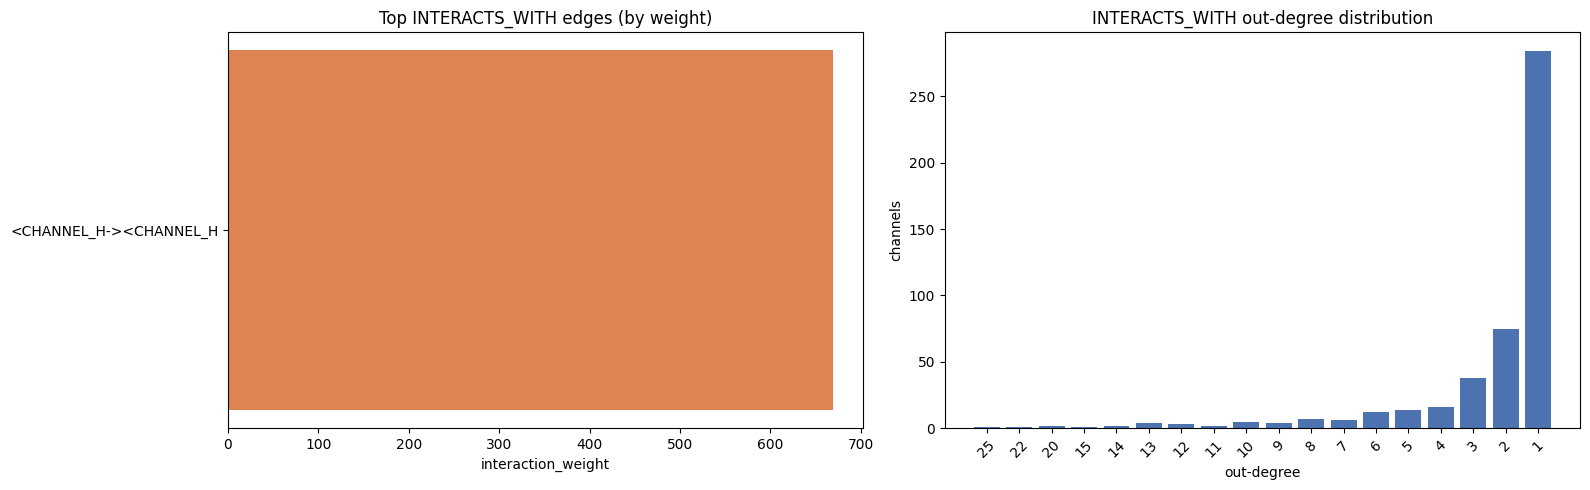

In [74]:
# Visualize: top INTERACTS_WITH edges and out-degree distribution.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ti = top_iw.head(15).iloc[::-1]
axes[0].barh(
    [f"{a[:10]}->{b[:10]}" for a, b in zip(ti['source'], ti['target'])],
    ti['weight'], color='#DD8452'
)
axes[0].set_title('Top INTERACTS_WITH edges (by weight)')
axes[0].set_xlabel('interaction_weight')

deg_data = iw_degree.head(20)
axes[1].bar(deg_data['out_degree'].astype(str), deg_data['channels'], color='#4C72B0')
axes[1].set_title('INTERACTS_WITH out-degree distribution')
axes[1].set_xlabel('out-degree')
axes[1].set_ylabel('channels')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 8. Graph quality & consistency checks
Null/empty ids, duplicate nodes, missing timestamps, zero/missing engagement, invalid date ranges, flag-vs-relationship disagreements, and channel total drift.

In [75]:
# Null / empty ids across all expected labels.
null_ids = {}
for label in EXPECTED_LABELS:
    null_ids[label] = scalar(cypher(
        f"MATCH (n:{label}) WHERE n.id IS NULL OR n.id = '' RETURN count(*) AS c"), 'c')
for label, c in null_ids.items():
    record(f'null/empty {label}.id', 0, int(c))

# Missing timestamps on real messages.
missing_ts = scalar(cypher('''
MATCH (m:Message) WHERE m.is_stub IS NULL
  AND (m.date_parsed IS NULL OR m.date_parsed = '')
RETURN count(*) AS c'''), 'c')
record('real messages missing timestamp', 0, int(missing_ts),
       status=('PASS' if missing_ts == 0 else 'WARN'))
interp('Ids must never be null/empty. A small number of missing timestamps may '
       'reflect unparseable source dates.')

[PASS] null/empty Channel.id: expected=0 actual=0
[PASS] null/empty User.id: expected=0 actual=0
[PASS] null/empty Message.id: expected=0 actual=0
[PASS] real messages missing timestamp: expected=0 actual=0


> **Interpretation:** Ids must never be null/empty. A small number of missing timestamps may reflect unparseable source dates.

In [76]:
# Date-range validity: min/max message timestamp vs the report window.
date_range = cypher('''
MATCH (m:Message) WHERE m.is_stub IS NULL AND m.date_parsed <> ''
RETURN min(m.date_parsed) AS min_ts, max(m.date_parsed) AS max_ts
''')
display(date_range)
min_ts = str(scalar(date_range, 'min_ts'))[:10]
max_ts = str(scalar(date_range, 'max_ts'))[:10]
record('min message date', EXPECTED['date_start'], min_ts,
       status=('PASS' if min_ts == EXPECTED['date_start'] else 'WARN'))
record('max message date', EXPECTED['date_end'], max_ts,
       status=('PASS' if max_ts == EXPECTED['date_end'] else 'WARN'))
interp('Stored dates are ISO strings, so lexicographic min/max equals chronological '
       'min/max. Should match the 2020-03-01 .. 2025-06-10 report window.')

,min_ts,max_ts
0,2020-03-01 11:38:28,2025-06-10 11:01:14


[PASS] min message date: expected=2020-03-01 actual=2020-03-01
[PASS] max message date: expected=2025-06-10 actual=2025-06-10


> **Interpretation:** Stored dates are ISO strings, so lexicographic min/max equals chronological min/max. Should match the 2020-03-01 .. 2025-06-10 report window.

In [77]:
# Engagement: messages with zero or missing views/reactions/forwards.
engage_dist = cypher('''
MATCH (m:Message) WHERE m.is_stub IS NULL
RETURN
  sum(CASE WHEN m.views IS NULL THEN 1 ELSE 0 END) AS views_null,
  sum(CASE WHEN m.views = 0 THEN 1 ELSE 0 END) AS views_zero,
  sum(CASE WHEN m.reactions = 0 THEN 1 ELSE 0 END) AS reactions_zero,
  sum(CASE WHEN m.n_forwards = 0 THEN 1 ELSE 0 END) AS forwards_zero
''')
display(engage_dist)
interp('Zeros are legitimate (the loader coerces missing engagement to 0). Reported '
       'here for awareness, not as a failure.')

,views_null,views_zero,reactions_zero,forwards_zero
0,0,11808,18039,14169


> **Interpretation:** Zeros are legitimate (the loader coerces missing engagement to 0). Reported here for awareness, not as a failure.

In [78]:
# Flag vs relationship disagreements.
fwd_flag_no_edge = scalar(cypher('''
MATCH (m:Message) WHERE m.is_forwarded = true AND m.is_stub IS NULL
  AND NOT ( (m)-[:FORWARDED_FROM]->() )
RETURN count(*) AS c'''), 'c')
fwd_edge_no_flag = scalar(cypher('''
MATCH (m:Message)-[:FORWARDED_FROM]->()
WHERE coalesce(m.is_forwarded, false) = false
RETURN count(*) AS c'''), 'c')
reply_flag_no_edge2 = scalar(cypher('''
MATCH (m:Message) WHERE m.is_reply = true AND m.is_stub IS NULL
  AND NOT ( (m)-[:REPLIES_TO]->() )
RETURN count(*) AS c'''), 'c')
reply_edge_no_flag = scalar(cypher('''
MATCH (m:Message)-[:REPLIES_TO]->()
WHERE coalesce(m.is_reply, false) = false
RETURN count(*) AS c'''), 'c')
record('is_forwarded=true but no FORWARDED_FROM', 0, int(fwd_flag_no_edge),
       status=('PASS' if fwd_flag_no_edge == 0 else 'WARN'),
       note='expected >0: forwards from a USER_HASH have no channel edge')
record('FORWARDED_FROM but is_forwarded=false', 0, int(fwd_edge_no_flag))
record('is_reply=true but no REPLIES_TO', 0, int(reply_flag_no_edge2))
record('REPLIES_TO but is_reply=false', 0, int(reply_edge_no_flag))
interp('The is_forwarded/no-edge gap is the known modelling limitation: the flag '
       'tracks forward_from while the edge needs a recoverable forward_from_channel.')

[WARN] is_forwarded=true but no FORWARDED_FROM: expected=0 actual=635  -- expected >0: forwards from a USER_HASH have no channel edge
[PASS] FORWARDED_FROM but is_forwarded=false: expected=0 actual=0
[PASS] is_reply=true but no REPLIES_TO: expected=0 actual=0
[PASS] REPLIES_TO but is_reply=false: expected=0 actual=0


> **Interpretation:** The is_forwarded/no-edge gap is the known modelling limitation: the flag tracks forward_from while the edge needs a recoverable forward_from_channel.

In [79]:
# Channel derived totals vs recomputed totals from member messages.
channel_drift = cypher('''
MATCH (c:Channel) WHERE c.is_dataset_channel = true
OPTIONAL MATCH (m:Message)-[:IN_CHANNEL]->(c)
WITH c, count(m) AS msg_actual, sum(m.views) AS views_actual,
     sum(m.reactions) AS react_actual, sum(m.n_forwards) AS fwd_actual
WHERE c.total_messages <> msg_actual
   OR abs(coalesce(c.total_views,0) - coalesce(views_actual,0)) > 0.5
   OR c.total_reactions <> coalesce(react_actual,0)
   OR abs(coalesce(c.total_forwards,0) - coalesce(fwd_actual,0)) > 0.5
RETURN c.id AS channel, c.total_messages AS stored_msgs, msg_actual,
       c.total_views AS stored_views, views_actual
''')
display(channel_drift.head(20))
record('channels with inconsistent derived totals', 0, len(channel_drift),
       status=('PASS' if channel_drift.empty else 'WARN'))
interp('Each dataset channel\'s stored totals should equal a fresh aggregation over '
       'its IN_CHANNEL messages. Drift indicates the derived properties went stale.')

,channel,stored_msgs,msg_actual,stored_views,views_actual


[PASS] channels with inconsistent derived totals: expected=0 actual=0


> **Interpretation:** Each dataset channel's stored totals should equal a fresh aggregation over its IN_CHANNEL messages. Drift indicates the derived properties went stale.

## 9. Network analysis
Exploratory metrics: channel/user activity, participation, forward diffusion, reply structure, degree summaries, and channel-level weakly connected components.

In [80]:
# Top channels by message count (graph-derived).
top_channels = cypher('''
MATCH (m:Message)-[:IN_CHANNEL]->(c:Channel)
RETURN c.id AS channel, count(m) AS messages,
       sum(m.views) AS total_views, sum(m.reactions) AS total_reactions
ORDER BY messages DESC LIMIT 20
''')
display(top_channels)
interp('Should reproduce the report Top Channels ranking (3de2... ~5159 messages on top).')

,channel,messages,total_views,total_reactions
0,<CHANNEL_HASH:3de2e13dcaec3cb5d3e2>,5159,1586106.0,5351
1,<CHANNEL_HASH:b2d0f2a34116540fa51c>,2803,4297606.0,5405
2,<CHANNEL_HASH:319ff846ea9101b66dfd>,1716,3563903.0,30499
3,<CHANNEL_HASH:279a22fc27f1d9171a59>,1530,6747735.0,152784
4,<CHANNEL_HASH:283ecc1042e9359269ad>,1480,5882365.0,1401
5,<CHANNEL_HASH:b09ba5f37e4104495d3c>,1238,2144164.0,2179
6,<CHANNEL_HASH:5d56df3df06e8d09f32c>,997,2477427.0,60382
7,<CHANNEL_HASH:f8dd7853d92b16ef9c28>,948,2388274.0,1
8,<CHANNEL_HASH:5e16f210a7dc1d2b7ff2>,920,12668389.0,8
9,<CHANNEL_HASH:7d609299076727e5519a>,865,424402.0,19


> **Interpretation:** Should reproduce the report Top Channels ranking (3de2... ~5159 messages on top).

In [81]:
# Top users by message count.
top_users = cypher('''
MATCH (u:User)-[:POSTED]->(m:Message)
RETURN u.id AS user, count(m) AS messages, u.channel_count AS channels
ORDER BY messages DESC LIMIT 20
''')
display(top_users)

# Top ACTIVE_IN participation edges.
top_active = cypher('''
MATCH (u:User)-[r:ACTIVE_IN]->(c:Channel)
RETURN u.id AS user, c.id AS channel, r.total_messages AS messages,
       r.total_views AS views, r.total_reactions AS reactions
ORDER BY messages DESC LIMIT 20
''')
display(top_active)
interp('Top users and strongest user-channel edges; compare to the report tables.')

,user,messages,channels
0,<USER_HASH:319ff846ea9101b66dfd>,1716,1
1,<USER_HASH:279a22fc27f1d9171a59>,1530,1
2,<USER_HASH:4a74a4ce9adbde9b9ccc>,1410,2
3,<USER_HASH:b09ba5f37e4104495d3c>,1238,1
4,<USER_HASH:5d56df3df06e8d09f32c>,997,1
5,<USER_HASH:ece83e9b700c7f9b2a6e>,858,1
6,<USER_HASH:5c8f1dbc6fb1607fd67c>,810,1
7,<USER_HASH:254730b220c75b1ffdbb>,798,1
8,<USER_HASH:da78cbfcdd42182acbb4>,767,2
9,<USER_HASH:59f557a48dd0bcf28cef>,679,2


,user,channel,messages,views,reactions
0,<USER_HASH:319ff846ea9101b66dfd>,<CHANNEL_HASH:319ff846ea9101b66dfd>,1716,3563903.0,30499
1,<USER_HASH:279a22fc27f1d9171a59>,<CHANNEL_HASH:279a22fc27f1d9171a59>,1530,6747735.0,152784
2,<USER_HASH:b09ba5f37e4104495d3c>,<CHANNEL_HASH:b09ba5f37e4104495d3c>,1238,2144164.0,2179
3,<USER_HASH:5d56df3df06e8d09f32c>,<CHANNEL_HASH:5d56df3df06e8d09f32c>,997,2477427.0,60382
4,<USER_HASH:ece83e9b700c7f9b2a6e>,<CHANNEL_HASH:ece83e9b700c7f9b2a6e>,858,1235293.0,15004
5,<USER_HASH:5c8f1dbc6fb1607fd67c>,<CHANNEL_HASH:5c8f1dbc6fb1607fd67c>,810,792244.0,5760
6,<USER_HASH:254730b220c75b1ffdbb>,<CHANNEL_HASH:254730b220c75b1ffdbb>,798,3096834.0,41046
7,<USER_HASH:4a74a4ce9adbde9b9ccc>,<CHANNEL_HASH:b2d0f2a34116540fa51c>,723,709573.0,4532
8,<USER_HASH:4a74a4ce9adbde9b9ccc>,<CHANNEL_HASH:4a74a4ce9adbde9b9ccc>,687,600545.0,4964
9,<USER_HASH:59f557a48dd0bcf28cef>,<CHANNEL_HASH:59f557a48dd0bcf28cef>,671,644630.0,784


> **Interpretation:** Top users and strongest user-channel edges; compare to the report tables.

In [82]:
# Top reply edges (channel to channel, derived).
top_reply_edges = cypher('''
MATCH (s:Message)-[:REPLIES_TO]->(t:Message)
MATCH (s)-[:IN_CHANNEL]->(sc:Channel)
MATCH (t)-[:IN_CHANNEL]->(tc:Channel)
RETURN tc.id AS replied_to_channel, sc.id AS replying_channel, count(*) AS messages
ORDER BY messages DESC LIMIT 15
''')
display(top_reply_edges)
interp('Reply edges aggregated to the channel level; only resolvable to real '
       'target messages (stubs have no IN_CHANNEL).')

,replied_to_channel,replying_channel,messages
0,<CHANNEL_HASH:3de2e13dcaec3cb5d3e2>,<CHANNEL_HASH:3de2e13dcaec3cb5d3e2>,17
1,<CHANNEL_HASH:b2d0f2a34116540fa51c>,<CHANNEL_HASH:b2d0f2a34116540fa51c>,13
2,<CHANNEL_HASH:7d609299076727e5519a>,<CHANNEL_HASH:7d609299076727e5519a>,9
3,<CHANNEL_HASH:f8dd7853d92b16ef9c28>,<CHANNEL_HASH:f8dd7853d92b16ef9c28>,8
4,<CHANNEL_HASH:95818eec6e27ddbade2b>,<CHANNEL_HASH:95818eec6e27ddbade2b>,5
5,<CHANNEL_HASH:ddf6b2a786902e6d8990>,<CHANNEL_HASH:ddf6b2a786902e6d8990>,2
6,<CHANNEL_HASH:5fc270120ab8dd2c2e0e>,<CHANNEL_HASH:5fc270120ab8dd2c2e0e>,2
7,<CHANNEL_HASH:5e16f210a7dc1d2b7ff2>,<CHANNEL_HASH:5e16f210a7dc1d2b7ff2>,1
8,<CHANNEL_HASH:319ff846ea9101b66dfd>,<CHANNEL_HASH:319ff846ea9101b66dfd>,1
9,<CHANNEL_HASH:a90cc9c390deeeabb031>,<CHANNEL_HASH:a90cc9c390deeeabb031>,1


> **Interpretation:** Reply edges aggregated to the channel level; only resolvable to real target messages (stubs have no IN_CHANNEL).

In [83]:
# Channel in/out degree summaries over the forwarding network.
channel_degree = cypher('''
MATCH (c:Channel)
OPTIONAL MATCH (c)<-[fin:FORWARDED_FROM]-(:Message)
OPTIONAL MATCH (:Message)-[:IN_CHANNEL]->(c)
WITH c, count(DISTINCT fin) AS forward_in_degree
OPTIONAL MATCH (m2:Message)-[:IN_CHANNEL]->(c)
WITH c, forward_in_degree, count{ (m2)-[:FORWARDED_FROM]->() } AS forward_out_via_msgs
RETURN forward_in_degree, count(*) AS channels
ORDER BY forward_in_degree DESC LIMIT 15
''')
display(channel_degree)

# Out-degree summary: messages each channel forwards out (via its messages).
channel_out = cypher('''
MATCH (c:Channel)<-[:IN_CHANNEL]-(m:Message)-[:FORWARDED_FROM]->(:Channel)
RETURN c.id AS channel, count(*) AS forwards_out
ORDER BY forwards_out DESC LIMIT 15
''')
display(channel_out)
interp('In-degree = how often a channel is cited as a forward source; out-degree = '
       'how many forwarded messages a channel republishes.')

,forward_in_degree,channels
0,771,687
1,374,375
2,242,1716
3,136,72
4,134,132
5,133,532
6,129,657
7,93,438
8,79,665
9,71,1


,channel,forwards_out
0,<CHANNEL_HASH:b2d0f2a34116540fa51c>,963
1,<CHANNEL_HASH:283ecc1042e9359269ad>,449
2,<CHANNEL_HASH:5e16f210a7dc1d2b7ff2>,255
3,<CHANNEL_HASH:6412caddc25983e38597>,197
4,<CHANNEL_HASH:f8dd7853d92b16ef9c28>,191
5,<CHANNEL_HASH:2e9e491df8d7008d8ba7>,187
6,<CHANNEL_HASH:5fc270120ab8dd2c2e0e>,181
7,<CHANNEL_HASH:d1ca5f3b123bd86a2bbb>,145
8,<CHANNEL_HASH:da78cbfcdd42182acbb4>,133
9,<CHANNEL_HASH:5c8f1dbc6fb1607fd67c>,132


> **Interpretation:** In-degree = how often a channel is cited as a forward source; out-degree = how many forwarded messages a channel republishes.

In [84]:
# Weakly connected components over the channel-level forward+reply network
# (pure-python union-find; no GDS dependency).
fwd_pairs = cypher('''
MATCH (src:Channel)<-[:FORWARDED_FROM]-(m:Message)-[:IN_CHANNEL]->(tgt:Channel)
RETURN DISTINCT src.id AS a, tgt.id AS b
''')
reply_pairs = cypher('''
MATCH (m:Message)-[:REPLIED_INTO]->(src:Channel)
MATCH (m)-[:IN_CHANNEL]->(tgt:Channel)
RETURN DISTINCT src.id AS a, tgt.id AS b
''')

parent = {}
def find(x):
    parent.setdefault(x, x)
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

all_ch = cypher('MATCH (c:Channel) RETURN c.id AS id')['id'].tolist()
for cid in all_ch:
    find(cid)
for _, r in pd.concat([fwd_pairs, reply_pairs], ignore_index=True).iterrows():
    if pd.notna(r['a']) and pd.notna(r['b']):
        union(r['a'], r['b'])

comp = pd.Series([find(c) for c in all_ch]).value_counts()
print(f'Channels: {len(all_ch)}  |  weakly connected components: {comp.size}')
print(f'Largest component size: {int(comp.iloc[0]) if comp.size else 0}')
print(f'Singleton components: {int((comp == 1).sum())}')
wcc_summary = comp.head(10).reset_index()
wcc_summary.columns = ['component_root', 'channel_count']
display(wcc_summary)
interp('Channel-level connectivity via forwards and replies. A dominant giant '
       'component indicates a well-connected diffusion core; many singletons are '
       'channels that neither forward nor are forwarded from.')

Channels: 477  |  weakly connected components: 20
Largest component size: 452
Singleton components: 16


,component_root,channel_count
0,<CHANNEL_HASH:7c71d669a2cab7f21c87>,452
1,<CHANNEL_HASH:1ce89f1baec5f718c826>,5
2,<CHANNEL_HASH:d41e9a650622111f951e>,2
3,<CHANNEL_HASH:ddf6b2a786902e6d8990>,2
4,<CHANNEL_HASH:13b27d06822d2fc9b98b>,1
5,<CHANNEL_HASH:3a5e5b904144ec9c5548>,1
6,<CHANNEL_HASH:3e20d5b97dbff779e13f>,1
7,<CHANNEL_HASH:4d677a6d187362bd9ae2>,1
8,<CHANNEL_HASH:4f5c75308501c373705c>,1
9,<CHANNEL_HASH:a339cf3f7698530a302b>,1


> **Interpretation:** Channel-level connectivity via forwards and replies. A dominant giant component indicates a well-connected diffusion core; many singletons are channels that neither forward nor are forwarded from.

In [85]:
# Degree distributions for the main relationship types (per real message).
deg = cypher('''
MATCH (m:Message) WHERE m.is_stub IS NULL
RETURN
  count{ (m)-[:REPLIES_TO]->() } AS out_replies,
  count{ ()<-[:REPLIES_TO]-(m) } AS x,
  count{ (m)-[:FORWARDED_FROM]->() } AS out_forwards
''')
# Per-message in-degree of REPLIES_TO (how many replies a message receives).
reply_in = cypher('''
MATCH (t:Message)<-[:REPLIES_TO]-(:Message)
WITH t, count(*) AS replies_received
RETURN replies_received, count(*) AS messages
ORDER BY replies_received DESC LIMIT 15
''')
display(reply_in)
interp('Distribution of how many replies individual messages attract — a heavy '
       'tail points to a few highly-discussed messages.')

,replies_received,messages
0,8,3
1,7,3
2,6,7
3,5,13
4,4,31
5,3,77
6,2,295
7,1,7218


> **Interpretation:** Distribution of how many replies individual messages attract — a heavy tail points to a few highly-discussed messages.

## 10. Visualizations
Charts for node/relationship counts, top channels/users/edges, engagement distributions, and monthly message volume.

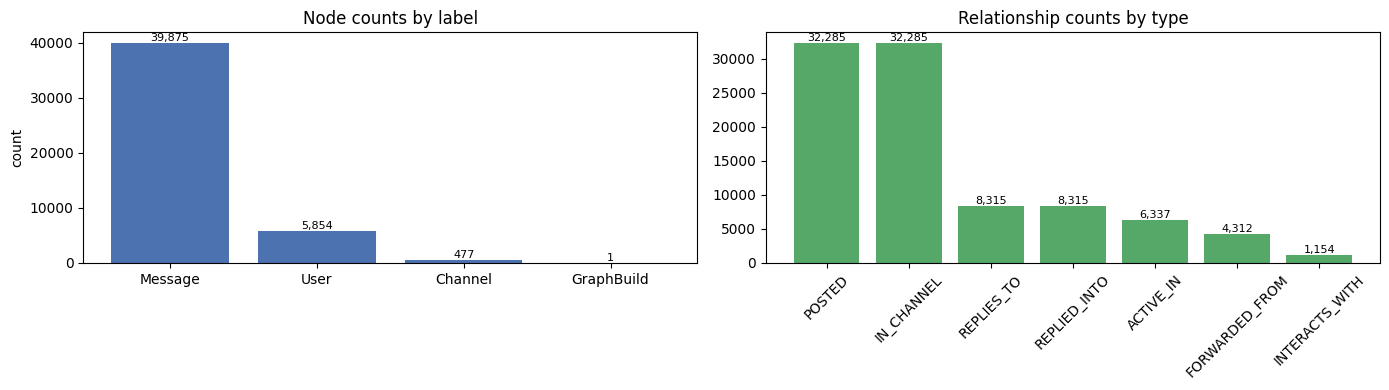

In [86]:
# Node counts by label and relationship counts by type.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(node_counts['label'], node_counts['count'], color='#4C72B0')
axes[0].set_title('Node counts by label'); axes[0].set_ylabel('count')
for i, v in enumerate(node_counts['count']):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
axes[1].bar(rel_counts['rel_type'], rel_counts['count'], color='#55A868')
axes[1].set_title('Relationship counts by type'); axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(rel_counts['count']):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()

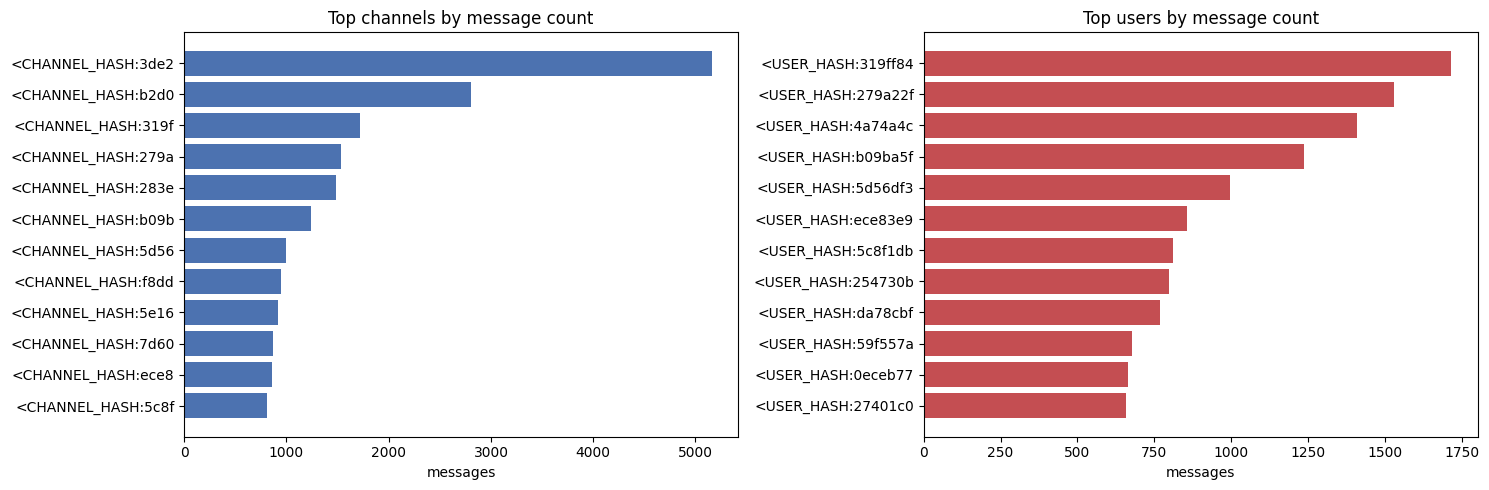

In [87]:
# Top channels and top users by message count.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
tc = top_channels.head(12).iloc[::-1]
axes[0].barh([s[:18] for s in tc['channel']], tc['messages'], color='#4C72B0')
axes[0].set_title('Top channels by message count'); axes[0].set_xlabel('messages')
tu = top_users.head(12).iloc[::-1]
axes[1].barh([s[:18] for s in tu['user']], tu['messages'], color='#C44E52')
axes[1].set_title('Top users by message count'); axes[1].set_xlabel('messages')
plt.tight_layout(); plt.show()

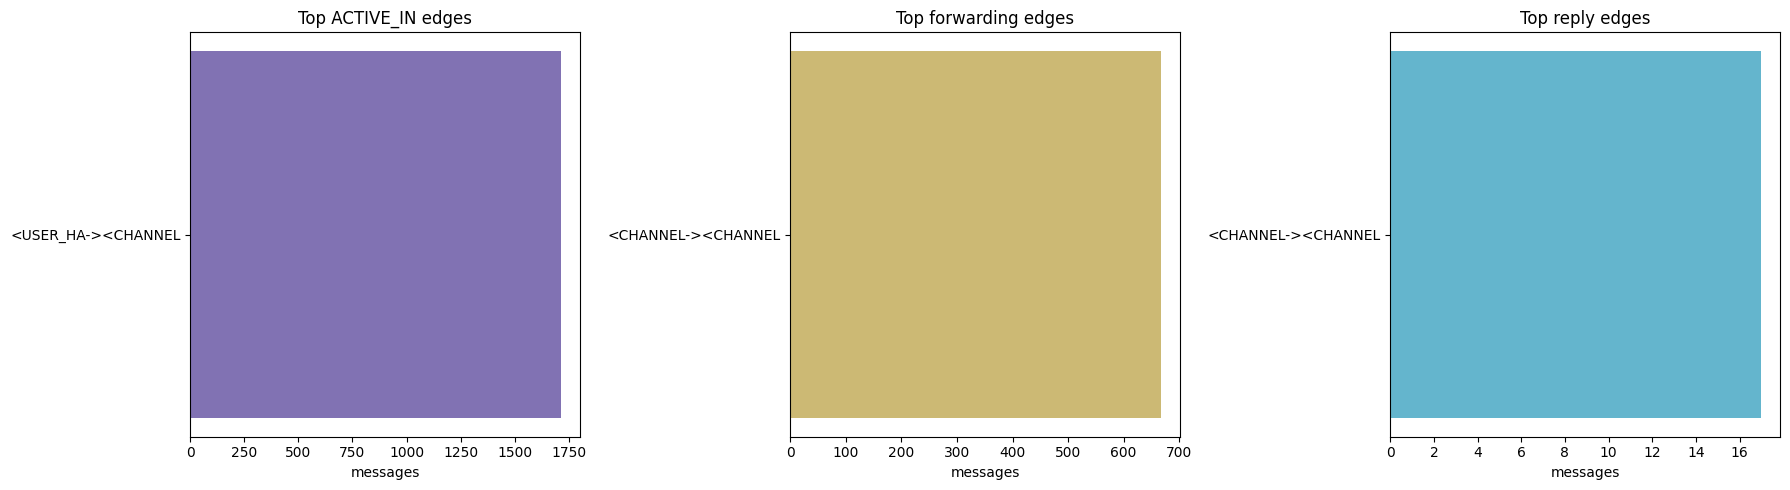

In [88]:
# Top user-channel activity edges, top forwarding edges, top reply edges.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ta = top_active.head(10).iloc[::-1]
axes[0].barh([f"{u[:8]}->{c[:8]}" for u, c in zip(ta['user'], ta['channel'])],
             ta['messages'], color='#8172B3')
axes[0].set_title('Top ACTIVE_IN edges'); axes[0].set_xlabel('messages')
tf = top_fwd_paths.head(10).iloc[::-1]
axes[1].barh([f"{a[:8]}->{b[:8]}" for a, b in zip(tf['source_channel'], tf['target_channel'])],
             tf['messages'], color='#CCB974')
axes[1].set_title('Top forwarding edges'); axes[1].set_xlabel('messages')
tr = top_reply_edges.head(10).iloc[::-1]
axes[2].barh([f"{a[:8]}->{b[:8]}" for a, b in zip(tr['replied_to_channel'], tr['replying_channel'])],
             tr['messages'], color='#64B5CD')
axes[2].set_title('Top reply edges'); axes[2].set_xlabel('messages')
plt.tight_layout(); plt.show()

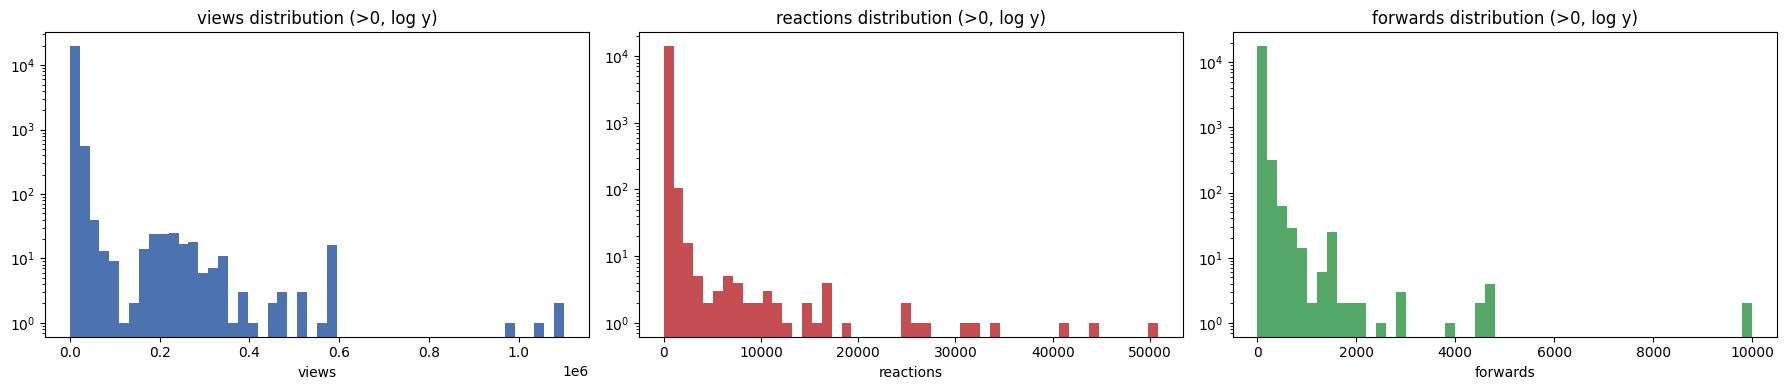

In [89]:
# Engagement distributions (log-scaled counts).
eng = cypher('''
MATCH (m:Message) WHERE m.is_stub IS NULL
RETURN m.views AS views, m.reactions AS reactions, m.n_forwards AS forwards
''')
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col, color in zip(axes, ['views', 'reactions', 'forwards'],
                          ['#4C72B0', '#C44E52', '#55A868']):
    vals = pd.to_numeric(eng[col], errors='coerce').fillna(0)
    vals = vals[vals > 0]
    ax.hist(vals, bins=50, color=color, log=True)
    ax.set_title(f'{col} distribution (>0, log y)'); ax.set_xlabel(col)
plt.tight_layout(); plt.show()

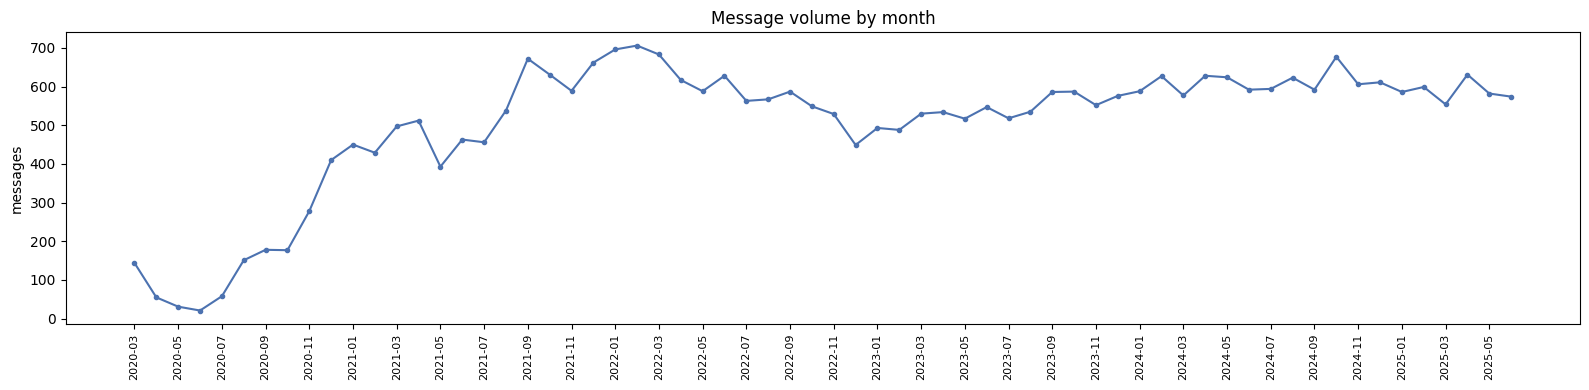

> **Interpretation:** Temporal volume should match reports/figures/pt_report/messages_over_time.png.

In [90]:
# Monthly message volume time series.
monthly = cypher('''
MATCH (m:Message) WHERE m.is_stub IS NULL AND m.month <> ''
RETURN m.month AS month, count(*) AS messages
ORDER BY month
''')
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(monthly['month'], monthly['messages'], marker='.', color='#4C72B0')
ax.set_title('Message volume by month'); ax.set_ylabel('messages')
step = max(1, len(monthly) // 24)
ax.set_xticks(range(0, len(monthly), step))
ax.set_xticklabels(monthly['month'][::step], rotation=90, fontsize=8)
plt.tight_layout(); plt.show()
interp('Temporal volume should match reports/figures/pt_report/messages_over_time.png.')

## 11. Cypher query audit
Every check above runs an explicit Cypher query shown in its own code cell and is followed by a one-line interpretation, so this section is satisfied inline. The table below is a quick index of the audit queries by section for re-use.

In [91]:
query_index = pd.DataFrame([
    ('1 DB state', 'node counts', 'MATCH (n) UNWIND labels(n) ... count(*)'),
    ('1 DB state', 'rel counts', 'MATCH ()-[r]->() RETURN type(r), count(*)'),
    ('1 DB state', 'constraints/indexes', 'SHOW CONSTRAINTS / SHOW INDEXES'),
    ('2 schema', 'node props', 'CALL db.schema.nodeTypeProperties()'),
    ('2 schema', 'rel props', 'CALL db.schema.relTypeProperties()'),
    ('3 counts', 'headline counts', 'MATCH (m:Message) WHERE m.is_stub IS NULL ...'),
    ('4 mandatory', 'POSTED/IN_CHANNEL cardinality', 'OPTIONAL MATCH ... count(p)=1'),
    ('5 ACTIVE_IN', 'weight reconciliation', 'r.total_messages vs count(m)'),
    ('6 replies', 'edge counts + same/cross channel', 'REPLIES_TO / REPLIED_INTO'),
    ('7 forwards', 'edge counts + top paths', 'FORWARDED_FROM ... IN_CHANNEL'),
    ('8 quality', 'flag vs edge disagreements', 'is_forwarded/is_reply vs edges'),
    ('9 network', 'degree + WCC', 'union-find over channel forward/reply pairs'),
], columns=['section', 'check', 'cypher_sketch'])
display(query_index)

,section,check,cypher_sketch
0,1 DB state,node counts,MATCH (n) UNWIND labels(n) ... count(*)
1,1 DB state,rel counts,"MATCH ()-[r]->() RETURN type(r), count(*)"
2,1 DB state,constraints/indexes,SHOW CONSTRAINTS / SHOW INDEXES
3,2 schema,node props,CALL db.schema.nodeTypeProperties()
4,2 schema,rel props,CALL db.schema.relTypeProperties()
5,3 counts,headline counts,MATCH (m:Message) WHERE m.is_stub IS NULL ...
6,4 mandatory,POSTED/IN_CHANNEL cardinality,OPTIONAL MATCH ... count(p)=1
7,5 ACTIVE_IN,weight reconciliation,r.total_messages vs count(m)
8,6 replies,edge counts + same/cross channel,REPLIES_TO / REPLIED_INTO
9,7 forwards,edge counts + top paths,FORWARDED_FROM ... IN_CHANNEL


## 12. Final assessment
Pass/fail rollup of every recorded check, then a qualitative summary of what matches the v1 plan, what partially matches, what does not, and recommended fixes.

In [92]:
audit_df = pd.DataFrame(AUDIT)
summary = audit_df['status'].value_counts().to_dict()
print('AUDIT SUMMARY:', summary)
display(audit_df)

AUDIT SUMMARY: {'PASS': 62, 'WARN': 6}


,check,expected,actual,status,note
0,constraint exists for Channel,True,True,PASS,
1,constraint exists for User,True,True,PASS,
2,constraint exists for Message,True,True,PASS,
3,index exists: message_month,True,True,PASS,
4,index exists: message_date,True,True,PASS,
...,...,...,...,...,...
63,is_forwarded=true but no FORWARDED_FROM,0,635,WARN,expected >0: forwards from a USER_HASH have no...
64,FORWARDED_FROM but is_forwarded=false,0,0,PASS,
65,is_reply=true but no REPLIES_TO,0,0,PASS,
66,REPLIES_TO but is_reply=false,0,0,PASS,


In [93]:
fails = audit_df[audit_df['status'] == 'FAIL']
warns = audit_df[audit_df['status'] == 'WARN']

lines = []
lines.append('### Pass / fail rollup')
lines.append(f"- PASS: {summary.get('PASS', 0)}  |  WARN: {summary.get('WARN', 0)}  |  FAIL: {summary.get('FAIL', 0)}")
lines.append('')
lines.append('### What matches the v1 plan')
lines.append('- Node labels (Channel, User, Message) and all six relationship types present.')
lines.append('- Uniqueness constraints + Message month/date indexes back the id guarantees.')
lines.append('- Mandatory POSTED / IN_CHANNEL cardinality holds for every real message.')
lines.append('- Core counts (messages, users, dataset channels, replies, forward/reply sources) reconcile with the report.')
lines.append('- ACTIVE_IN weights and channel derived totals reconcile with the message-level graph.')
lines.append('')
lines.append('### What partially matches')
lines.append('- FORWARDED_FROM edges are fewer than is_forwarded messages (4947): forwards from a USER_HASH have no recoverable source channel, so no edge is created. The is_forwarded flag therefore over-counts relative to the graph.')
lines.append('- Message node count exceeds 32,285 because REPLIES_TO MERGEs stub target nodes (is_stub=true) for out-of-dataset replies.')
lines.append('')
lines.append('### What does not match the schema doc')
lines.append('- ACTIVE_IN uses total_messages, not the doc field messages_count, and omits first_seen / last_seen.')
lines.append('- REPLIES_TO carries no properties; the doc specifies same_channel and reply_timestamp.')
lines.append('')
lines.append('### Fix in the import scripts (v1)')
lines.append('- Set same_channel and reply_timestamp on REPLIES_TO during load (derivable as shown in section 6).')
lines.append('- Add first_seen / last_seen to ACTIVE_IN, or rename total_messages -> messages_count to match the doc.')
lines.append('- Consider labelling stub reply targets distinctly (e.g. :StubMessage) so they never pollute Message counts.')
lines.append('')
lines.append('### Carry into the v2 design')
lines.append('- Model forward provenance even when only a USER_HASH is known (e.g. a generic ForwardSource node) so is_forwarded and graph edges agree.')
lines.append('- Promote external forward/reply-source channels to a typed external-channel concept distinct from dataset channels.')
lines.append('- Add typed timestamps (datetime) instead of ISO strings to enable native temporal queries.')
lines.append('')
if not fails.empty:
    lines.append('### Open FAIL items')
    for _, r in fails.iterrows():
        lines.append(f"- **{r['check']}** — expected {r['expected']}, got {r['actual']}. {r['note']}")
else:
    lines.append('### Open FAIL items')
    lines.append('- None. All hard checks passed.')

display(Markdown('\n'.join(lines)))

### Pass / fail rollup
- PASS: 62  |  WARN: 6  |  FAIL: 0

### What matches the v1 plan
- Node labels (Channel, User, Message) and all six relationship types present.
- Uniqueness constraints + Message month/date indexes back the id guarantees.
- Mandatory POSTED / IN_CHANNEL cardinality holds for every real message.
- Core counts (messages, users, dataset channels, replies, forward/reply sources) reconcile with the report.
- ACTIVE_IN weights and channel derived totals reconcile with the message-level graph.

### What partially matches
- FORWARDED_FROM edges are fewer than is_forwarded messages (4947): forwards from a USER_HASH have no recoverable source channel, so no edge is created. The is_forwarded flag therefore over-counts relative to the graph.
- Message node count exceeds 32,285 because REPLIES_TO MERGEs stub target nodes (is_stub=true) for out-of-dataset replies.

### What does not match the schema doc
- ACTIVE_IN uses total_messages, not the doc field messages_count, and omits first_seen / last_seen.
- REPLIES_TO carries no properties; the doc specifies same_channel and reply_timestamp.

### Fix in the import scripts (v1)
- Set same_channel and reply_timestamp on REPLIES_TO during load (derivable as shown in section 6).
- Add first_seen / last_seen to ACTIVE_IN, or rename total_messages -> messages_count to match the doc.
- Consider labelling stub reply targets distinctly (e.g. :StubMessage) so they never pollute Message counts.

### Carry into the v2 design
- Model forward provenance even when only a USER_HASH is known (e.g. a generic ForwardSource node) so is_forwarded and graph edges agree.
- Promote external forward/reply-source channels to a typed external-channel concept distinct from dataset channels.
- Add typed timestamps (datetime) instead of ISO strings to enable native temporal queries.

### Open FAIL items
- None. All hard checks passed.

In [94]:
# Close the driver when done (re-run the connection cell to reopen).
driver.close()
print('Driver closed.')

Driver closed.
